Your Name and PRN:
- Name: Pranay Sagar                      
- Name:Anhad Rajan
- PRN : 260240128027                    
- PRN : 260240128006
- Date : 04/05/2026    

# Deep Neural Network
## Assignment A01

In [47]:
###-----------------
### Import Libraries
###-----------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns

from sklearn import datasets
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

In [48]:
###----------------
### Some parameters
###----------------

# Directory locations
inpDir = 'notebooks/datasets/breast_cancer_mod.csv' # Set path of input directory as per your system
outDir = '../output' # Set path of Output directory as per your system

RANDOM_STATE = 24 # REMEMBER: to remove at the time of promotion to production
np.random.seed(RANDOM_STATE)
rng = np.random.default_rng(seed = RANDOM_STATE) # Set Random Seed for reproducible  results

NOISE = 0.2
EPOCHS = 200  # number of epochs
ALPHA = 0.1  # learning rate
N_SAMPLES = 1000

# parameters for Matplotlib
params = {'legend.fontsize': 'medium',
          'figure.figsize': (15, 6),
          'axes.labelsize': 'large',
          'axes.titlesize':'large',
          'xtick.labelsize':'large',
          'ytick.labelsize':'large'
         }

plt.rcParams.update(params)

CMAP = plt.cm.coolwarm
plt.style.use('seaborn-v0_8-darkgrid') # plt.style.use('ggplot')

In [49]:
df = pd.read_csv("breast_cancer_mod.csv")

print("Shape          :", df.shape)
print("Columns        :", df.columns.tolist())
print("Target column  :", df.columns[-1])
print("\nFirst 3 rows:")
df.head(3)

Shape          : (569, 31)
Columns        : ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension', 'radius error', 'texture error', 'perimeter error', 'area error', 'smoothness error', 'compactness error', 'concavity error', 'concave points error', 'symmetry error', 'fractal dimension error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst smoothness', 'worst compactness', 'worst concavity', 'worst concave points', 'worst symmetry', 'worst fractal dimension', 'target']
Target column  : target

First 3 rows:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,0,0,0,0,0,0,0,0,0,1,...,0,0,0,1,1,0,0,1,1,0
1,0,1,0,1,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,1,0
2,0,1,0,0,0,0,0,0,0,1,...,1,0,1,0,1,1,0,1,1,0


In [50]:
###----------------------------
### Prepare Features & Target
###----------------------------

# Separate features and target
# Handles both 'target' named column or last-column convention
if 'target' in df.columns:
    y = df['target'].values
    X = df.drop(columns=['target']).values
else:
    # Last column is the target
    y = df.iloc[:, -1].values
    X = df.iloc[:, :-1].values

# Ensure y is integer binary {0, 1}
# If target is string like 'M'/'B', encode it
if y.dtype == object:
    from sklearn.preprocessing import LabelEncoder
    y = LabelEncoder().fit_transform(y)
    print("Target was string — label-encoded to {0, 1}")

# Binarize features at their column-wise median
# MP Neuron ONLY accepts binary inputs {0, 1}
X_bin = (X >= np.median(X, axis=0)).astype(int)

# Train / Test split
X_train, X_test, y_train, y_test = train_test_split(
    X_bin, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"\nTrain size : {X_train.shape}")
print(f"Test  size : {X_test.shape}")
print(f"Features   : {X_train.shape[1]}  (all binary after median binarization)")
print(f"Classes    : {np.unique(y)}  →  0=malignant, 1=benign")


Train size : (455, 30)
Test  size : (114, 30)
Features   : 30  (all binary after median binarization)
Classes    : [0 1]  →  0=malignant, 1=benign


In [51]:
###----------------------------
### MP Neuron Model
###----------------------------

class MPNeuron:
    """
    McCulloch-Pitts Neuron (1943).
    - All inputs must be binary {0, 1}
    - All weights are fixed at 1 (not learned)
    - Only the threshold b is learned via exhaustive search
    - Output: y_hat = 1  if  sum(x) >= b  else  0
    """

    def __init__(self):
        self.b = None
        self.n_features = None

    def _predict_one(self, x, b):
        return int(np.sum(x) >= b)

    def predict(self, X, b=None):
        b = b if b is not None else self.b
        return np.array([self._predict_one(x, b) for x in X])

    def fit(self, X_train, y_train):
        self.n_features = X_train.shape[1]
        best_acc = -1

        # Search over all candidate thresholds b ∈ {0, 1, ..., n_features}
        for b_candidate in range(self.n_features + 1):
            y_pred = self.predict(X_train, b=b_candidate)
            acc = accuracy_score(y_train, y_pred)
            if acc > best_acc:
                best_acc = acc
                self.b = b_candidate

        print(f"Best threshold  b = {self.b}")
        print(f"Train accuracy    = {best_acc:.4f}  ({best_acc*100:.2f}%)")
        return self

    def score(self, X, y):
        return accuracy_score(y, self.predict(X))

In [52]:
###----------------------------
### Train MP Neuron
###----------------------------

mp = MPNeuron()
mp.fit(X_train, y_train)

Best threshold  b = 27
Train accuracy    = 0.8505  (85.05%)


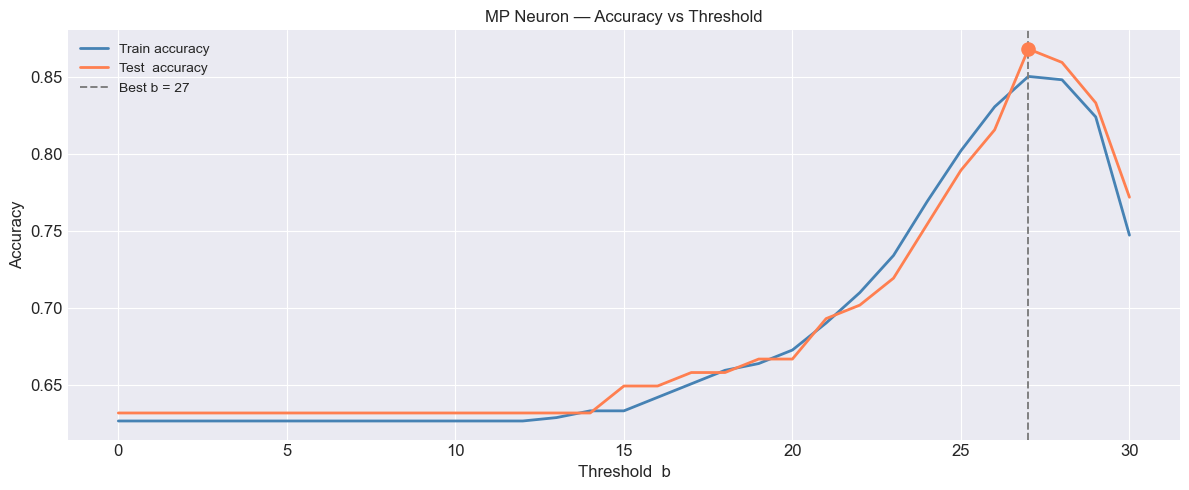

In [53]:
###-------------------------------------------
### Accuracy vs Threshold — training & test
###-------------------------------------------

thresholds  = range(mp.n_features + 1)
train_accs  = [accuracy_score(y_train, mp.predict(X_train, b=b)) for b in thresholds]
test_accs   = [accuracy_score(y_test,  mp.predict(X_test,  b=b)) for b in thresholds]

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(thresholds, train_accs, label='Train accuracy', color='steelblue', linewidth=2)
ax.plot(thresholds, test_accs,  label='Test  accuracy', color='coral',     linewidth=2)
ax.axvline(mp.b, color='gray', linestyle='--', linewidth=1.4, label=f'Best b = {mp.b}')
ax.scatter([mp.b], [test_accs[mp.b]], color='coral', zorder=5, s=90)
ax.set_xlabel('Threshold  b')
ax.set_ylabel('Accuracy')
ax.set_title('MP Neuron — Accuracy vs Threshold')
ax.legend()
plt.tight_layout()
plt.show()

Test Accuracy = 0.8684  (86.84%)



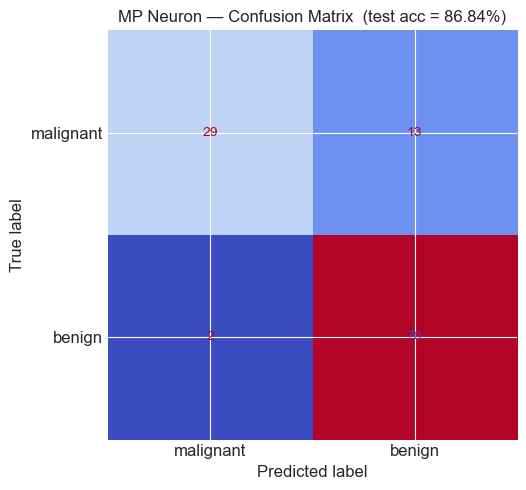

True  Negatives (malignant correctly flagged) : 29
False Positives (malignant missed)            : 13
False Negatives (benign wrongly flagged)      : 2
True  Positives (benign correctly identified) : 70

               precision    recall  f1-score   support

   malignant       0.94      0.69      0.79        42
      benign       0.84      0.97      0.90        72

    accuracy                           0.87       114
   macro avg       0.89      0.83      0.85       114
weighted avg       0.88      0.87      0.86       114



In [54]:
###----------------------------
### Evaluation
###----------------------------

y_pred   = mp.predict(X_test)
test_acc = accuracy_score(y_test, y_pred)
print(f"Test Accuracy = {test_acc:.4f}  ({test_acc*100:.2f}%)\n")

# Confusion matrix
cm   = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['malignant', 'benign'])

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap=CMAP, colorbar=False)
ax.set_title(f'MP Neuron — Confusion Matrix  (test acc = {test_acc:.2%})')
plt.tight_layout()
plt.show()

# Detailed breakdown
tn, fp, fn, tp = cm.ravel()
print(f"True  Negatives (malignant correctly flagged) : {tn}")
print(f"False Positives (malignant missed)            : {fp}")
print(f"False Negatives (benign wrongly flagged)      : {fn}")
print(f"True  Positives (benign correctly identified) : {tp}")

# Classification report
print("\n", classification_report(y_test, y_pred, target_names=['malignant', 'benign']))